# Define model

In [1]:
import datetime
import os
import shutil
import sys
import time
from collections import Counter

import numpy as np
import path
import torch
import torch.nn.functional as F
import sys
from pathlib import Path

parent_dir = Path.cwd().parent.resolve()

if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from data import data
from logger import get_logger
from prepare import accuracy, fetch_data, initialise

In [2]:
from argparse import Namespace

args = Namespace(
    data="coauthorship",
    dataset="dblp",
    model_name="UniGCNII",
    first_aggregate="mean",
    second_aggregate="sum",
    add_self_loop=False,
    use_norm=False,
    activation="relu",
    nlayer=64,
    nhid=8,
    nhead=8,
    dropout=0.6,
    input_drop=0.6,
    attn_drop=0.6,
    lr=0.01,
    wd=5e-4,
    epochs=200,
    n_runs=10,
    gpu=0,
    seed=1,
    patience=200,
    nostdout=False,
    split=1,
    out_dir="runs/elbow_labeled",
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Override configuration values here when needed, for example:
# args.epochs = 200
# args.n_runs = 10

torch.manual_seed(args.seed)
np.random.seed(args.seed)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = str(args.gpu)
os.environ["PYTHONHASHSEED"] = str(args.seed)

dataname = f"{args.data}_{args.dataset}"
out_dir = path.Path(
    f"./{args.out_dir}/{args.model_name}_{args.nlayer}_{dataname}/seed_{args.seed}"
)

if out_dir.exists():
    shutil.rmtree(out_dir)
out_dir.makedirs_p()

baselogger = get_logger("base logger", f"{out_dir}/logging.log", not args.nostdout)
resultlogger = get_logger("result logger", f"{out_dir}/result.log", not args.nostdout)
baselogger.info(args)
resultlogger.info(args)

Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.01, wd=0.0005, epochs=200, n_runs=10, gpu=0, seed=1, patience=200, nostdout=False, split=1, out_dir='runs/elbow_labeled')
Namespace(data='coauthorship', dataset='dblp', model_name='UniGCNII', first_aggregate='mean', second_aggregate='sum', add_self_loop=False, use_norm=False, activation='relu', nlayer=64, nhid=8, nhead=8, dropout=0.6, input_drop=0.6, attn_drop=0.6, lr=0.01, wd=0.0005, epochs=200, n_runs=10, gpu=0, seed=1, patience=200, nostdout=False, split=1, out_dir='runs/elbow_labeled')


# Filter out patterns of a frequency threshold - Training with labeled simplets

In [3]:
import math
import os
import pickle

import numpy as np
from scipy.sparse import csr_matrix


def onehot(labels):
    """
    Convert integer class labels into one-hot vectors.
    """
    classes = sorted(set(labels))
    onehot_mapping = {
        class_id: np.identity(len(classes))[index, :]
        for index, class_id in enumerate(classes)
    }

    return np.array(
        list(map(onehot_mapping.get, labels)),
        dtype=np.int32,
    )


def load_data(d):
    """
    Load the hypergraph, features, and labels.

    Expected files:
        hypergraph.pickle
        feature_simplet.pickle
        labels.pickle
    """
    with open(os.path.join(d, "hypergraph.pickle"), "rb") as handle:
        hypergraph = pickle.load(handle)
        print("number of hyperedges is", len(hypergraph))

    with open(
        os.path.join(d, "feature_simplet.pickle"), "rb"
    ) as handle:
        features = pickle.load(handle).todense()

    with open(os.path.join(d, "labels.pickle"), "rb") as handle:
        labels = onehot(pickle.load(handle))

    return {
        "hypergraph": hypergraph,
        "features": features,
        "labels": labels,
        "n": features.shape[0],
    }


def extract_frequency(pattern, line_number=None):
    """
    Extract the frequency at the beginning of a pattern.

    Example:
        "4.0-[(0,0), (1,0)]-(1)" -> 4.0
    """
    frequency_text, separator, _ = pattern.partition("-")

    if not separator:
        location = (
            f" at mining-file line {line_number}"
            if line_number is not None
            else ""
        )
        raise ValueError(
            f"Cannot extract frequency from pattern{location}: {pattern!r}"
        )

    try:
        frequency = float(frequency_text)
    except ValueError as exception:
        location = (
            f" at mining-file line {line_number}"
            if line_number is not None
            else ""
        )
        raise ValueError(
            f"Invalid pattern frequency{location}: {frequency_text!r}"
        ) from exception

    if not math.isfinite(frequency) or frequency < 0:
        raise ValueError(
            f"Pattern frequency must be finite and non-negative, "
            f"got {frequency}"
        )

    return frequency


def read_pattern_records(pattern_file):
    """
    Read all patterns and their frequencies.

    Metadata before the separator line is skipped. Results are sorted
    from highest frequency to lowest frequency.

    Returns:
        List of (pattern_string, frequency) tuples.
    """
    records = []
    seen = set()
    reading_patterns = False

    with open(pattern_file, "r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            line = line.strip()

            if not line:
                continue

            if line in seen:
                raise ValueError(
                    f"Duplicate pattern at mining-file line "
                    f"{line_number}: {line}"
                )

            frequency = extract_frequency(line, line_number)

            seen.add(line)
            records.append((line, frequency))

    # Python sorting is stable, so equal-frequency patterns retain
    # their original file order.
    records.sort(key=lambda record: record[1], reverse=True)

    return records


def read_patterns(pattern_file, min_frequency=0.0):
    """
    Read, sort, and filter patterns by frequency.

    Args:
        pattern_file: FreSCo mining-result file.
        min_frequency: Minimum frequency required for a pattern.

    Returns:
        patterns: surviving patterns sorted by decreasing frequency.
        frequencies: corresponding frequency list.
    """
    if min_frequency < 0:
        raise ValueError(
            f"min_frequency must be non-negative, got {min_frequency}"
        )

    records = read_pattern_records(pattern_file)

    # Create the sorted lists before filtering.
    sorted_patterns = [pattern for pattern, _ in records]
    sorted_frequencies = [frequency for _, frequency in records]

    surviving_patterns = []
    surviving_frequencies = []

    for pattern, frequency in zip(
        sorted_patterns,
        sorted_frequencies,
    ):
        if frequency >= min_frequency:
            surviving_patterns.append(pattern)
            surviving_frequencies.append(frequency)

    return surviving_patterns, surviving_frequencies


def read_vertex_images(image_file):
    """
    Read the vertex-image occurrence map.

    Expected format:
        pattern_string<TAB>vertex_id
    """
    pairs = []

    with open(image_file, "r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            line = line.rstrip("\r\n")

            if not line.strip():
                continue

            try:
                pattern, vertex_text = line.rsplit("\t", maxsplit=1)
            except ValueError as exception:
                raise ValueError(
                    f"Invalid occMap line {line_number}: expected "
                    "'<pattern>\\t<vertex id>'"
                ) from exception

            pattern = pattern.strip()

            try:
                vertex = int(vertex_text.strip())
            except ValueError as exception:
                raise ValueError(
                    f"Invalid vertex ID at occMap line {line_number}: "
                    f"{vertex_text!r}"
                ) from exception

            pairs.append((pattern, vertex))

    return pairs


def build_sparse_matrix(patterns, vertex_pairs, num_vertices):
    """
    Construct sparse matrix A where:

        A[i, j] = 1

    iff vertex i appears as an image of pattern j.
    """
    if num_vertices < 0:
        raise ValueError(
            f"num_vertices must be non-negative, got {num_vertices}"
        )

    pattern_to_col = {
        pattern: column
        for column, pattern in enumerate(patterns)
    }

    rows = []
    cols = []

    for pattern, vertex in vertex_pairs:
        if pattern not in pattern_to_col:
            raise ValueError(
                "Occurrence map references an unexpected pattern: "
                f"{pattern}"
            )

        if not 0 <= vertex < num_vertices:
            raise IndexError(
                f"Vertex ID {vertex} is outside [0, {num_vertices})"
            )

        rows.append(vertex)
        cols.append(pattern_to_col[pattern])

    values = np.ones(len(rows), dtype=np.float32)

    matrix = csr_matrix(
        (values, (rows, cols)),
        shape=(num_vertices, len(patterns)),
        dtype=np.float32,
    )

    # Duplicate coordinates are summed by CSR construction.
    # Convert the matrix back to binary values.
    matrix.sum_duplicates()
    matrix.data[:] = 1.0

    return matrix


def build_feature_matrix(
    data,
    pattern_file,
    image_file,
    min_frequency=0.0,
):
    """
    Build a feature matrix using patterns meeting min_frequency.

    Columns are sorted by decreasing pattern frequency.

    Returns:
        matrix:
            CSR matrix shaped
            (number_of_vertices, number_of_surviving_patterns).

        patterns:
            Surviving patterns in matrix-column order.

        frequencies:
            Frequency of each surviving pattern in column order.
    """
    all_records = read_pattern_records(pattern_file)

    all_patterns = {
        pattern
        for pattern, _ in all_records
    }

    patterns = [
        pattern
        for pattern, frequency in all_records
        if frequency >= min_frequency
    ]

    frequencies = [
        frequency
        for _, frequency in all_records
        if frequency >= min_frequency
    ]

    surviving_pattern_set = set(patterns)
    vertex_pairs = read_vertex_images(image_file)

    filtered_vertex_pairs = []

    for pattern, vertex in vertex_pairs:
        if pattern not in all_patterns:
            raise ValueError(
                "Occurrence map references a pattern that is not "
                f"present in the mining file: {pattern}"
            )

        # Ignore occurrences belonging to patterns removed by the
        # minimum-frequency threshold.
        if pattern in surviving_pattern_set:
            filtered_vertex_pairs.append((pattern, vertex))

    num_vertices = int(data["features"].shape[0])

    matrix = build_sparse_matrix(
        patterns,
        filtered_vertex_pairs,
        num_vertices,
    )

    return matrix, patterns, frequencies

In [4]:
dataset_directory = "../data/coauthorship/dblp"
dataset = load_data(dataset_directory)

feature_matrix, patterns, frequencies = build_feature_matrix(
    data=dataset,
    pattern_file="/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
    image_file="/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
    min_frequency=200,
)

print(feature_matrix.shape)
print(frequencies)

number of hyperedges is 22363
(41302, 69)
[3868.0, 3127.0, 2603.0, 2304.0, 2082.0, 1855.0, 1603.0, 1578.0, 1503.0, 1387.0, 1368.0, 1294.0, 1288.0, 1103.0, 997.0, 962.0, 945.0, 889.0, 878.0, 839.0, 835.0, 833.0, 702.0, 691.0, 677.0, 661.0, 634.0, 589.0, 585.0, 583.0, 564.0, 526.0, 522.0, 516.0, 472.0, 463.0, 461.0, 448.0, 410.0, 406.0, 405.0, 395.0, 394.0, 385.0, 369.0, 363.0, 338.0, 336.0, 332.0, 329.0, 323.0, 320.0, 310.0, 306.0, 299.0, 293.0, 289.0, 281.0, 272.0, 252.0, 251.0, 240.0, 235.0, 232.0, 231.0, 230.0, 218.0, 218.0, 209.0]


In [5]:
import random
def as_float(value):
    """Convert a Python number or one-element tensor to a Python float."""
    if torch.is_tensor(value):
        return value.detach().cpu().item()
    return float(value)

def scalar(value):
    """Convert a scalar tensor or numeric value to float."""
    if torch.is_tensor(value):
        return value.detach().cpu().item()

    return float(value)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_feature_matrix(threshold, pattern_file, image_file):
    """
    Load the feature matrix saved for one frequency threshold.
    """
    feature_matrix, _, _ = build_feature_matrix(
        data=dataset,
        pattern_file=pattern_file,
        image_file=image_file,
        min_frequency=threshold,
    )

    return feature_matrix.tocsr()

def train_for_threshold(threshold, Y, G, pattern_file, image_file, args):
    feature_matrix = load_feature_matrix(threshold, pattern_file, image_file)

    number_of_patterns = feature_matrix.shape[1]

    # Convert the SciPy matrix into the dense tensor expected by UniGNN.
    # This may require substantial memory for large feature matrices.
    X = torch.as_tensor(
        feature_matrix.toarray(),
        dtype=torch.float32,
        device=device,
    )

    final_train_accuracies = []
    mean_epoch_accuracies = []

    for run in range(1, args.n_runs + 1):
        # Keep initialization reproducible across thresholds.
        set_seed(args.seed + run - 1)

        args.split = run

        _, train_idx, test_idx = data.load(args)

        train_idx = torch.as_tensor(
            train_idx,
            dtype=torch.long,
            device=device,
        )

        test_idx = torch.as_tensor(
            test_idx,
            dtype=torch.long,
            device=device,
        )

        model, optimizer = initialise(X, Y, G, args)
        epoch_train_accuracies = []

        start_time = time.time()

        for epoch in range(args.epochs):
            model.train()
            optimizer.zero_grad()

            output = model(X)
            loss = F.nll_loss(
                output[train_idx],
                Y[train_idx],
            )

            loss.backward()
            optimizer.step()

            model.eval()

            with torch.no_grad():
                output = model(X)

                train_accuracy = scalar(
                    accuracy(
                        output[train_idx],
                        Y[train_idx],
                    )
                )

            epoch_train_accuracies.append(train_accuracy)

        final_train_accuracies.append(
            epoch_train_accuracies[-1]
        )

        mean_epoch_accuracies.append(
            np.mean(epoch_train_accuracies)
        )

        print(
            f"threshold={threshold}, "
            f"run={run}/{args.n_runs}, "
            f"patterns={number_of_patterns}, "
            f"final train accuracy="
            f"{epoch_train_accuracies[-1]:.4f}, "
            f"time={time.time() - start_time:.2f}s"
        )

        del model, optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return {
        "threshold": int(threshold),
        "number_of_patterns": int(number_of_patterns),
        "mean_final_train_accuracy": float(
            np.mean(final_train_accuracies)
        ),
        "std_final_train_accuracy": float(
            np.std(final_train_accuracies)
        ),
        "mean_epoch_train_accuracy": float(
            np.mean(mean_epoch_accuracies)
        ),
    }

In [6]:
frequency_interval = list(np.arange(100, 2100, 100))
_, Y, G = fetch_data(args)
Y = Y.to(device)

experiment_results = []

for threshold in frequency_interval:
    result = train_for_threshold(
        threshold=threshold,
        Y=Y,
        G=G,
        pattern_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12",
        image_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/node_classification/AMiner/rerun1/AMiner_freq_100_minDim_0_maxSize_12occMap",
        args=args,
    )

    experiment_results.append(result)

    print(
        f"Completed threshold {threshold}: "
        f"{result['number_of_patterns']} patterns, "
        f"mean accuracy "
        f"{result['mean_final_train_accuracy']:.4f}"
    )

number of hyperedges is 22363
[0. 1. 2. ... 1. 1. 3.]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/data/cs.aau.dk/tungkvt/Nhi/UniGNN/prepare.py:138: RuntimeWarning: divide by zero encountered in power
  di = np.power(d, -1).flatten()


number of hyperedges is 22363
threshold=100, run=1/10, patterns=137, final train accuracy=90.0575, time=42.97s
number of hyperedges is 22363
threshold=100, run=2/10, patterns=137, final train accuracy=91.6092, time=42.76s
number of hyperedges is 22363
threshold=100, run=3/10, patterns=137, final train accuracy=91.6092, time=42.80s
number of hyperedges is 22363
threshold=100, run=4/10, patterns=137, final train accuracy=90.4023, time=42.80s
number of hyperedges is 22363
threshold=100, run=5/10, patterns=137, final train accuracy=91.6667, time=42.81s
number of hyperedges is 22363
threshold=100, run=6/10, patterns=137, final train accuracy=91.6092, time=42.80s
number of hyperedges is 22363
threshold=100, run=7/10, patterns=137, final train accuracy=91.1494, time=42.78s
number of hyperedges is 22363
threshold=100, run=8/10, patterns=137, final train accuracy=92.6437, time=42.78s
number of hyperedges is 22363
threshold=100, run=9/10, patterns=137, final train accuracy=91.0920, time=42.75s
n

In [7]:
import pandas as pd

results_df = pd.DataFrame(experiment_results)
results_df.to_csv(
    "frequency_training_results.csv",
    index=False,
)

results_df

,threshold,number_of_patterns,mean_final_train_accuracy,std_final_train_accuracy,mean_epoch_train_accuracy
0,100,137,91.258621,0.702210,90.152097
1,200,69,90.919540,0.694904,89.785373
2,300,54,90.959769,0.661320,89.642011
3,400,41,90.804597,0.647668,89.614109
4,500,34,90.793104,0.638837,89.475000
5,600,27,90.632184,0.485625,89.027902
6,700,23,90.534483,0.615802,88.898160
7,800,22,90.454023,0.587474,88.927931
8,900,17,89.890804,0.529516,87.819281
9,1000,14,89.810344,0.606615,87.636379


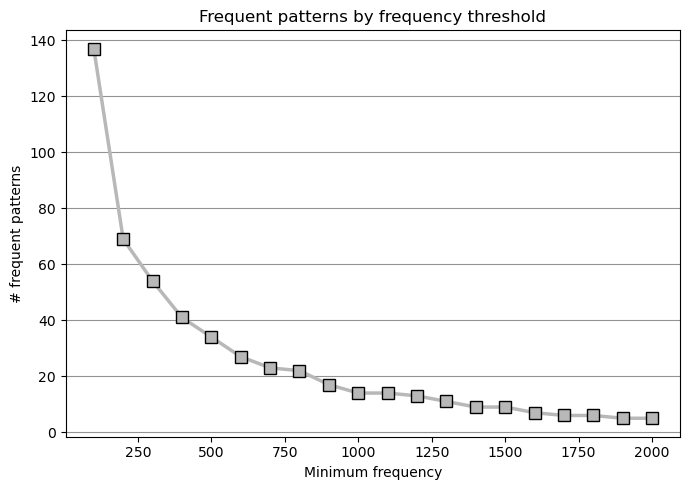

In [8]:
import matplotlib.pyplot as plt
thresholds = results_df["threshold"].to_numpy()
pattern_counts = results_df["number_of_patterns"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    thresholds,
    pattern_counts,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
)

plt.xlabel("Minimum frequency")
plt.ylabel("# frequent patterns")
plt.title("Frequent patterns by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("number_of_patterns_by_frequency.png", dpi=300)
plt.show()

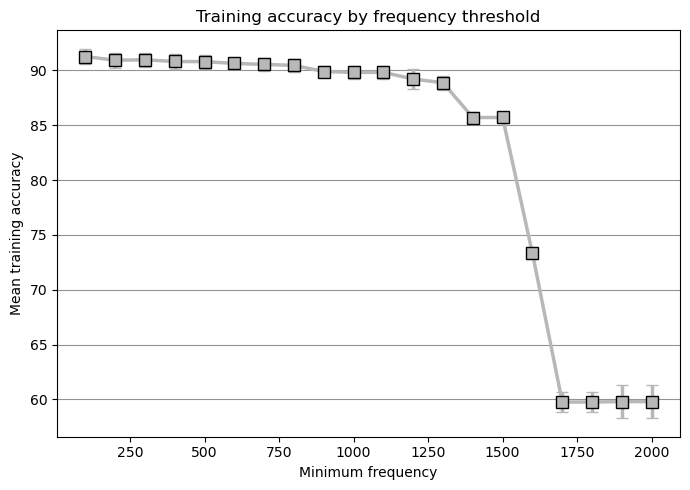

In [9]:
mean_accuracies = results_df[
    "mean_final_train_accuracy"
].to_numpy()

std_accuracies = results_df[
    "std_final_train_accuracy"
].to_numpy()

plt.figure(figsize=(7, 5))

plt.errorbar(
    thresholds,
    mean_accuracies,
    yerr=std_accuracies,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
    capsize=4,
)

plt.xlabel("Minimum frequency")
plt.ylabel("Mean training accuracy")
plt.title("Training accuracy by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("training_accuracy_by_frequency.png", dpi=300)
plt.show()

# Running unlabeled simplets

In [7]:
frequency_interval = list(np.arange(200, 2100, 100))
experiment_results_unlabeled = []
_, Y, G = fetch_data(args)
Y = Y.to(device)

for threshold in frequency_interval:
    result = train_for_threshold(
        threshold=threshold,
        Y=Y,
        G=G,
        pattern_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/dblp_uniGNN_old_unlabeld_simplices_PLMSC/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_200_minDim_0_maxSize_12",
        image_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/dblp_uniGNN_old_unlabeld_simplices_PLMSC/dblp_uniGNN_old_unlabeld_simplices_PLMSC_freq_200_minDim_0_maxSize_12occMap",
        args=args,
    )

    experiment_results_unlabeled.append(result)

    print(
        f"Completed threshold {threshold}: "
        f"{result['number_of_patterns']} patterns, "
        f"mean accuracy "
        f"{result['mean_final_train_accuracy']:.4f}"
    )

number of hyperedges is 22363
[0. 1. 2. ... 1. 1. 3.]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/data/cs.aau.dk/tungkvt/Nhi/UniGNN/prepare.py:138: RuntimeWarning: divide by zero encountered in power
  di = np.power(d, -1).flatten()


number of hyperedges is 22363
threshold=200, run=1/10, patterns=111, final train accuracy=41.4943, time=42.69s
number of hyperedges is 22363
threshold=200, run=2/10, patterns=111, final train accuracy=39.5402, time=42.54s
number of hyperedges is 22363
threshold=200, run=3/10, patterns=111, final train accuracy=42.1264, time=42.67s
number of hyperedges is 22363
threshold=200, run=4/10, patterns=111, final train accuracy=39.3103, time=42.74s
number of hyperedges is 22363
threshold=200, run=5/10, patterns=111, final train accuracy=40.1724, time=42.77s
number of hyperedges is 22363
threshold=200, run=6/10, patterns=111, final train accuracy=40.7471, time=42.78s
number of hyperedges is 22363
threshold=200, run=7/10, patterns=111, final train accuracy=41.1494, time=42.79s
number of hyperedges is 22363
threshold=200, run=8/10, patterns=111, final train accuracy=39.4253, time=42.78s
number of hyperedges is 22363
threshold=200, run=9/10, patterns=111, final train accuracy=40.5172, time=42.79s
n

In [8]:
import pandas as pd

results_df = pd.DataFrame(experiment_results_unlabeled)
results_df.to_csv(
    "frequency_training_results_unlabeled.csv",
    index=False,
)

results_df

,threshold,number_of_patterns,mean_final_train_accuracy,std_final_train_accuracy,mean_epoch_train_accuracy
0,200,111,40.586207,0.917311,38.481868
1,300,64,35.178161,0.744669,33.854052
2,400,45,32.637931,0.637620,31.556925
3,500,34,31.057471,0.808774,30.346379
4,600,28,30.563218,0.851584,29.833075
5,700,24,30.241379,0.691473,29.409626
6,800,21,30.178161,0.547307,29.349827
7,900,18,29.810345,0.806259,28.954282
8,1000,17,29.574713,0.469861,28.779741
9,1100,15,29.695402,0.654795,28.828362


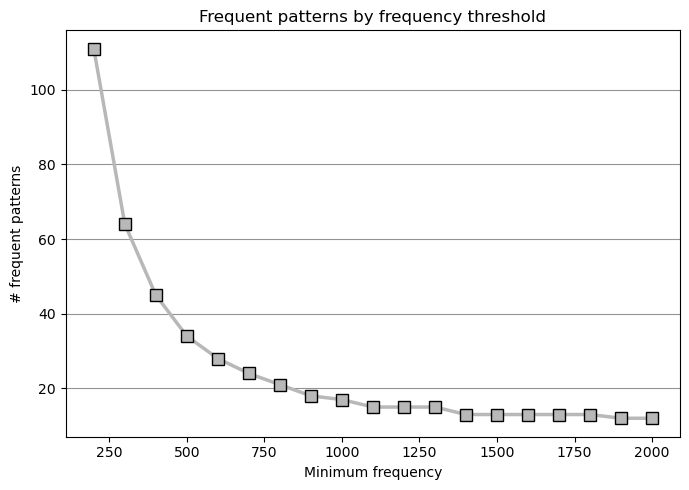

In [10]:
import matplotlib.pyplot as plt
thresholds = results_df["threshold"].to_numpy()
pattern_counts = results_df["number_of_patterns"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    thresholds,
    pattern_counts,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
)

plt.xlabel("Minimum frequency")
plt.ylabel("# frequent patterns")
plt.title("Frequent patterns by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("number_of_patterns_by_frequency.png", dpi=300)
plt.show()

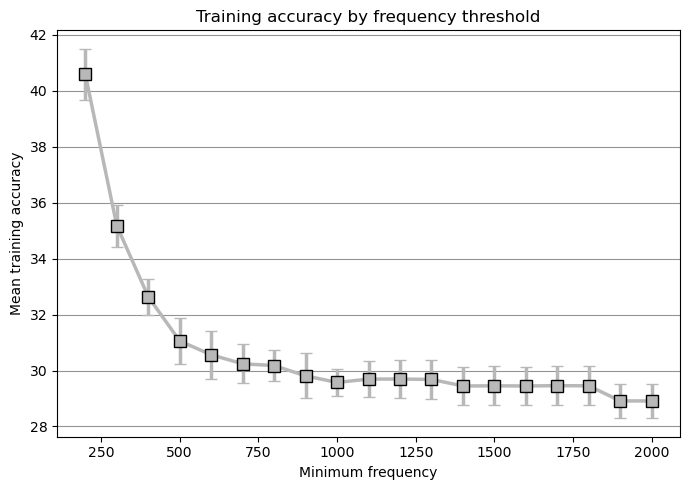

In [11]:
mean_accuracies = results_df[
    "mean_final_train_accuracy"
].to_numpy()

std_accuracies = results_df[
    "std_final_train_accuracy"
].to_numpy()

plt.figure(figsize=(7, 5))

plt.errorbar(
    thresholds,
    mean_accuracies,
    yerr=std_accuracies,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
    capsize=4,
)

plt.xlabel("Minimum frequency")
plt.ylabel("Mean training accuracy")
plt.title("Training accuracy by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("training_accuracy_by_frequency.png", dpi=300)
plt.show()

# Shuffling labels

In [ ]:
frequency_interval = list(np.arange(10, 2100, 100))
experiment_results_random = []
_, Y, G = fetch_data(args)
Y = Y.to(device)

for threshold in frequency_interval:
    result = train_for_threshold(
        threshold=threshold,
        Y=Y,
        G=G,
        pattern_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12",
        image_file = "/data/cs.aau.dk/tungkvt/Nhi/FreSCo_label/output/AMiner_randomly_permutate_vertex_label/AMiner_randomly_permutate_vertex_label_freq_10_minDim_0_maxSize_12occMap",
        args=args,
    )

    experiment_results_random.append(result)

    print(
        f"Completed threshold {threshold}: "
        f"{result['number_of_patterns']} patterns, "
        f"mean accuracy "
        f"{result['mean_final_train_accuracy']:.4f}"
    )

number of hyperedges is 22363
[0. 1. 2. ... 1. 1. 3.]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of hyperedges is 22363
threshold=10, run=1/10, patterns=411, final train accuracy=54.5977, time=42.44s
number of hyperedges is 22363
threshold=10, run=2/10, patterns=411, final train accuracy=56.4943, time=42.74s
number of hyperedges is 22363
threshold=10, run=3/10, patterns=411, final train accuracy=57.9310, time=42.82s
number of hyperedges is 22363
threshold=10, run=4/10, patterns=411, final train accuracy=55.4598, time=42.91s
number of hyperedges is 22363
threshold=10, run=5/10, patterns=411, final train accuracy=56.8965, time=42.91s
number of hyperedges is 22363
threshold=10, run=6/10, patterns=411, final train accuracy=55.6897, time=42.92s
number of hyperedges is 22363
threshold=10, run=7/10, patterns=411, final train accuracy=55.8046, time=42.92s
number of hyperedges

In [ ]:
results_df = pd.DataFrame(experiment_results_random)
results_df.to_csv(
    "frequency_training_results_random.csv",
    index=False,
)

results_df

In [ ]:
# import matplotlib.pyplot as plt
thresholds = results_df["threshold"].to_numpy()
pattern_counts = results_df["number_of_patterns"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    thresholds,
    pattern_counts,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
)

plt.xlabel("Minimum frequency")
plt.ylabel("# frequent patterns")
plt.title("Frequent patterns by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("number_of_patterns_by_frequency.png", dpi=300)
plt.show()

In [ ]:
mean_accuracies = results_df[
    "mean_final_train_accuracy"
].to_numpy()

std_accuracies = results_df[
    "std_final_train_accuracy"
].to_numpy()

plt.figure(figsize=(7, 5))

plt.errorbar(
    thresholds,
    mean_accuracies,
    yerr=std_accuracies,
    color="#b8b8b8",
    linewidth=2.5,
    marker="s",
    markersize=8,
    markerfacecolor="#b8b8b8",
    markeredgecolor="black",
    capsize=4,
)

plt.xlabel("Minimum frequency")
plt.ylabel("Mean training accuracy")
plt.title("Training accuracy by frequency threshold")
plt.grid(axis="y", color="#666666", alpha=0.7)
plt.tight_layout()
plt.savefig("training_accuracy_by_frequency.png", dpi=300)
plt.show()